In [2]:
from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
import torch
#  Enhanced MC Dropout function for full test set (FIXED: Initialize flat_confs/classes)
from tqdm import tqdm
import pandas as pd  # For summary table
import numpy as np 



image 1/1 /Users/alaindestinkarasira/Documents/test_UQ/po_380_jpg.rf.b3f6ad8cad2643d72102f3f0baa38d64.jpg: 640x640 3 pos, 1 wbc, 265.0ms
Speed: 3.3ms preprocess, 265.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


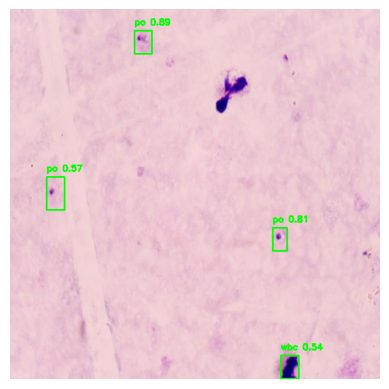

Local inference works!


In [ ]:
# Load model
# Load your downloaded weights
model_path = 'best.pt'  # e.g., 'C:/Downloads/best.pt'
model = YOLO(model_path)

# Test predict on a local image (e.g., from your test set)
img_path = 'po_380_jpg.rf.b3f6ad8cad2643d72102f3f0baa38d64.jpg'  # Copy a test image locally
results = model.predict(img_path, conf=0.25, iou=0.5)

# Viz (from your Cell 10)
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    label = f"{model.names[cls_id]} {conf:.2f}"
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.imshow(img)
plt.axis('off')
plt.show()


In [5]:
  # Ensure np is imported (from earlier cells)

def mc_dropout_predict(model, img_path, num_samples=10, conf_threshold=0.25, iou_threshold=0.5):
    """
    Predict with MC Dropout (same as before, but now returns per-detection details for logging).
    - Returns: results, list of dicts [{'class': 'pf', 'mean_conf': 0.8, 'unc': 0.012}, ...]
    """
    model.model.eval()
    torch.set_grad_enabled(True)  # Dropout on during inference

    all_confs_per_det = []  # List of lists: confs per detection
    all_classes_per_det = []  # Class per detection
    all_boxes_per_det = []    # Optional: boxes if needed

    with torch.no_grad():
        for _ in range(num_samples):
            results = model.predict(img_path, conf=conf_threshold, iou=iou_threshold, verbose=False)
            if results[0].boxes is not None:
                sample_confs = []
                sample_classes = []
                for box in results[0].boxes:
                    sample_confs.append(float(box.conf))
                    sample_classes.append(int(box.cls))
                if sample_confs:  # Only if detections
                    all_confs_per_det.append(sample_confs)
                    all_classes_per_det.append(sample_classes)
                    # all_boxes_per_det.append([box.xyxy[0].cpu().numpy() for box in results[0].boxes])  # Uncomment if needed

    # Process per detection: Assume we align by averaging across samples (simple: flatten and group by class occurrence)
    detections = []
    flat_confs = []  # FIXED: Initialize here to avoid UnboundLocalError
    flat_classes = []  # FIXED: Initialize here
    print(all_confs_per_det[1])
    print(all_classes_per_det[1])

    if all_confs_per_det:
        flat_confs = [conf for sublist in all_confs_per_det for conf in sublist]
        flat_classes = [cls for sublist in all_classes_per_det for cls in sublist]

        # Group by class (per-image avg)
        unique_classes = list(set(flat_classes))
        for cls in unique_classes:
            cls_confs = [conf for conf, c in zip(flat_confs, flat_classes) if c == cls]
            if cls_confs:
                mean_conf = np.mean(cls_confs)
                unc = np.var(cls_confs)
                detections.append({
                    'class_id': cls,
                    'class_name': model.names[cls],
                    'mean_conf': mean_conf,
                    'uncertainty': unc
                })

    avg_conf = np.mean(flat_confs) if flat_confs else 0.0
    avg_unc = np.mean([d['uncertainty'] for d in detections]) if detections else 0.0
    # print(flat_confs)
    print(f"Image: {os.path.basename(img_path)} | Samples: {num_samples} | Avg Conf: {avg_conf:.3f} | Avg Unc: {avg_unc:.3f}")
    return results[-1], detections, avg_conf, avg_unc  # Last results + per-det list + globals



In [ ]:
test_img_dir = os.path.join("test")
sample_img = os.listdir(test_img_dir)[3]
img_path = os.path.join(test_img_dir, sample_img)
results, dets, mean_conf, unc = mc_dropout_predict(model, img_path, num_samples=10)
# print(f"Sample: {len(dets)} detections logged.")

[0.8916870355606079, 0.8086414933204651, 0.5715773701667786, 0.5408532619476318]
[6, 6, 6, 8]
Image: po_380_jpg.rf.b3f6ad8cad2643d72102f3f0baa38d64.jpg | Samples: 10 | Avg Conf: 0.703 | Avg Unc: 0.009
